# Simply view some images

In [ ]:
from configs import get_avail_splits
from models import avail_models
from video_dataset import (
    get_wlasl_info,
    VideoDataset,
    )
import utils
import configs
import torch
from torch.utils.data import DataLoader
import json


#locals
from video_transforms import get_transform
from run_types import AdminInfo, AVAIL_SPLITS, SEED

In [ ]:
configs.set_seed(SEED)

### Frame prep function

In [6]:
figsize = (2,2)
show_frames = 16


def prep_next2(sample: dict[str, int | torch.Tensor]) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'
    
    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3: 
        frames = frames.permute(1, 0, 2, 3) #swap T and C
    return frames, int(label_num.squeeze())

## Setup


### Dataset

Available splits, and chosen set

In [7]:
av_splits: list[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000", "asl100_bottom"]
for s in av_splits:
    print(s)

split_idx = -1
split_name =av_splits[split_idx]
print('\n', f'Chosen split: {split_name}')

print('\n', 'Dataset info:')
test_info = get_wlasl_info(split_name, set_name="test")
print(json.dumps({k : str(v) for k, v in test_info.items()}, indent=4))

print('\n', "Num classes")
class_list = configs.get_class_list()
print(len(class_list))

asl100
asl300
asl1000
asl2000
asl100_bottom

 Chosen split: asl100_bottom

 Dataset info:
{
    "root": "../data/WLASL/WLASL2000",
    "labels": "../data/WLASL/preprocessed/labels/asl100_bottom",
    "label_suff": "num_instances.json",
    "set_name": "test"
}

 Num classes
2000


## Config

In [8]:
split_name=av_splits[split_idx]
config = configs.load_config(
    AdminInfo(
        model=avail_models()[0],
        dataset='wlasl',
        split=split_name,
        save_path='results',
        exp_no='0',
        recover=False,
        config_path='configfiles/asl100/MViTv2_S/exp016.toml',
        weight_path=None
    )
)
data_info = config.data
# print(json.dumps(data_info.model_dump(), indent=4))

## Visualise Training transform

Dataloader

In [ ]:
#Transform
aug_info = data_info.train_augs
assert aug_info is not None
transform, _, _ = get_transform(
    norm_dict=aug_info.norm_dict,
    temporal_aug=aug_info.temporal_aug,
    spatial_aug=aug_info.spatial_aug
)
#Dataset
assert aug_info is not None
aug_set = VideoDataset(
    set_info=test_info,
    # transforms=transform,  
)
#Dataloader
aug_loader = DataLoader(
    aug_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
#Iterable
iter_aug = iter(aug_loader)



# Looking at what the machine sees 


## Augmentation

frames: torch.Size([16, 3, 224, 224])
Class: who


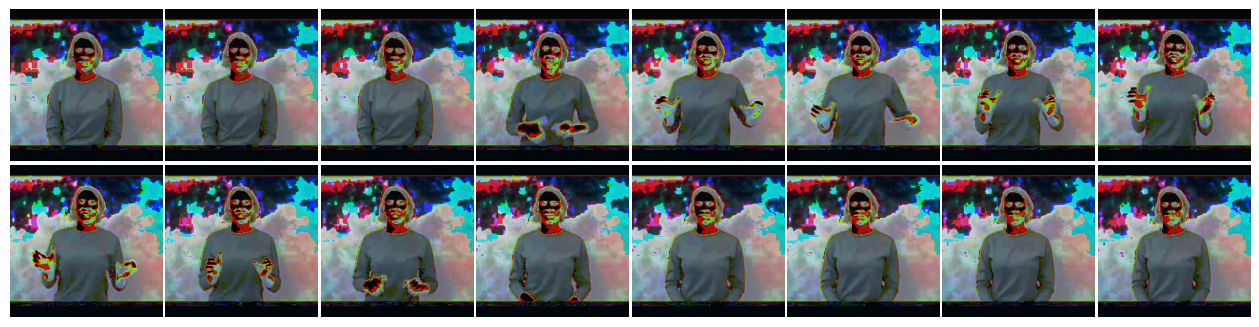

In [ ]:
# sample_aug = next(iter_aug)
sample = next(iter_aug)
auged = transform(sample['frames'].squeeze(dim=0))
sample_aug = sample.copy()
sample_aug.update({'frames': auged.unsqueeze(dim=0)})
frames_aug, label_num = prep_next2(sample_aug)
print(f"frames: {frames_aug.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_aug,show_frames, size=figsize)

# Conclusion:

seems to be working?